# 🔩 GC10-DET — Notebook Unificado de Treinamento

## O que este notebook faz

Este notebook treina **dois modelos** necessários para o pipeline completo do `app.py`:

1. **Fase 1 — EfficientNetV2-S (10 classes):** classificação de defeitos + bbox (salvo como `gc10det_cls_best.pt`)
2. **Fase 2 — EfficientNetV2-S (11 classes, OOD):** fine-tuning com classe `negative` para rejeitar imagens fora do domínio (salvo como `gc10det_cls_ood.pt`)
3. **Fase 3 — YOLOv8:** detecção com bounding boxes, treinado no GC10-DET com os XMLs Pascal VOC (salvo como `yolo_detector.pt`)

## Estrutura esperada de diretórios
```
projeto/
├── images/images/<classe>/*.jpg   (10 classes de defeito)
├── images/negative/*.jpg          (imagens OOD — criadas na Fase 2)
├── label/label/*.xml              (anotações Pascal VOC)
└── gc10det_unificado.ipynb
```

## Arquivos gerados
| Arquivo | Usado por |
|---|---|
| `gc10det_cls_best.pt` | Base para fine-tuning OOD |
| `gc10det_cls_ood.pt` | `app.py` — classificação + guard OOD |
| `yolo_detector.pt` | `app.py` — detecção com bbox |
| `detection_metadata.json` | `app.py` — limiares OOD |


## 0. Instalação de dependências

In [22]:
#!pip install ultralytics torch torchvision albumentations scikit-learn matplotlib seaborn pillow tqdm pyyaml opencv-python lxml --quiet


## 1. Imports e configuração global

In [23]:
import os, glob, json, random, shutil, tempfile, warnings
from collections import Counter
from pathlib import Path

import albumentations as A
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import yaml
from albumentations.pytorch import ToTensorV2
from lxml import etree
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchvision import transforms as T
from torchvision.models import efficientnet_v2_s, EfficientNet_V2_S_Weights
from tqdm.notebook import tqdm

warnings.filterwarnings('ignore')

SEED = 13
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'PyTorch : {torch.__version__}')
print(f'CUDA    : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
    print(f'VRAM    : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
print(f'Device  : {DEVICE}')


PyTorch : 2.11.0+cu128
CUDA    : True
GPU     : NVIDIA GeForce RTX 5090 Laptop GPU
VRAM    : 25.7 GB
Device  : cuda


## 2. Caminhos do projeto

In [24]:
# ── Altere DATASET_ROOT conforme seu ambiente ─────────────────────────────────
DATASET_ROOT = Path(r'/mnt/c/Users/cesar.macieira/Desktop/Trabalho/Python_312/analise-defeitos-superficies')

IMAGE_DIR  = DATASET_ROOT / 'images' / 'images'
LABEL_DIR  = DATASET_ROOT / 'label' / 'label'
NEG_DIR    = DATASET_ROOT / 'images' / 'negative'   # criado na Fase 2

if not LABEL_DIR.exists():
    LABEL_DIR = DATASET_ROOT / 'label'

WORK_DIR        = DATASET_ROOT
YOLO_DATASET_DIR = WORK_DIR / 'yolo_dataset'
YOLO_YAML       = WORK_DIR / 'gc10det.yaml'

# Arquivos de saída
CLS_BEST_PT  = WORK_DIR / 'gc10det_cls_best.pt'   # Fase 1
CLS_OOD_PT   = WORK_DIR / 'gc10det_cls_ood.pt'    # Fase 2
OUTPUT_MODEL = WORK_DIR / 'yolo_detector.pt'       # Fase 3
META_PATH    = WORK_DIR / 'detection_metadata.json'

print(f'Dataset root : {DATASET_ROOT}  — existe: {DATASET_ROOT.exists()}')
print(f'Images dir   : {IMAGE_DIR}  — existe: {IMAGE_DIR.exists()}')
print(f'Labels dir   : {LABEL_DIR}  — existe: {LABEL_DIR.exists()}')


Dataset root : /mnt/c/Users/cesar.macieira/Desktop/Trabalho/Python_312/analise-defeitos-superficies  — existe: True
Images dir   : /mnt/c/Users/cesar.macieira/Desktop/Trabalho/Python_312/analise-defeitos-superficies/images/images  — existe: True
Labels dir   : /mnt/c/Users/cesar.macieira/Desktop/Trabalho/Python_312/analise-defeitos-superficies/label/label  — existe: True


## 3. Mapeamento de classes

In [25]:
DEFECT_CLASSES = [
    'punching_hole', 'welding_line', 'crescent_gap', 'water_spot', 'oil_spot',
    'silk_spot', 'inclusion', 'rolled_pit', 'crease', 'waist_folding',
]
CLASS_NAMES   = DEFECT_CLASSES + ['negative']
N_DEFECTS     = len(DEFECT_CLASSES)   # 10
N_CLASSES     = len(CLASS_NAMES)       # 11
OOD_CLASS_IDX = 10

CLASS_PT = {
    'punching_hole': 'Puncionamento', 'welding_line': 'Linha de Solda',
    'crescent_gap': 'Fresta Crescente', 'water_spot': "Mancha d'Água",
    'oil_spot': 'Mancha de Óleo', 'silk_spot': 'Mancha Seda',
    'inclusion': 'Inclusão', 'rolled_pit': 'Cavidade Laminada',
    'crease': 'Dobra', 'waist_folding': 'Dobra de Cintura', 'negative': 'Negativo',
}

CLASS_TO_IDX = {name: i for i, name in enumerate(DEFECT_CLASSES)}

FOLDER_TO_CLASS = {
    'crescent_gap': 'crescent_gap', 'crescent gap': 'crescent_gap',
    'inclusion': 'inclusion', 'oil_spot': 'oil_spot', 'oil spot': 'oil_spot',
    'punching_hole': 'punching_hole', 'punching hole': 'punching_hole',
    'rolled_pit': 'rolled_pit', 'rolled pit': 'rolled_pit',
    'silk_spot': 'silk_spot', 'silk spot': 'silk_spot',
    'waist_folding': 'waist_folding', 'waist folding': 'waist_folding',
    'water_spot': 'water_spot', 'water spot': 'water_spot',
    'welding_line': 'welding_line', 'welding line': 'welding_line',
    'crease': 'crease',
}

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

print(f'Classes de defeito ({N_DEFECTS}):')
for i, c in enumerate(DEFECT_CLASSES):
    print(f'  {i}: {c} → {CLASS_PT[c]}')
print(f'Classe OOD (idx {OOD_CLASS_IDX}): negative')


Classes de defeito (10):
  0: punching_hole → Puncionamento
  1: welding_line → Linha de Solda
  2: crescent_gap → Fresta Crescente
  3: water_spot → Mancha d'Água
  4: oil_spot → Mancha de Óleo
  5: silk_spot → Mancha Seda
  6: inclusion → Inclusão
  7: rolled_pit → Cavidade Laminada
  8: crease → Dobra
  9: waist_folding → Dobra de Cintura
Classe OOD (idx 10): negative


## 4. Arquitetura do modelo — EfficientNetV2-S multi-output

In [26]:
class GC10MultiOutputNet(nn.Module):
    """EfficientNetV2-S com cabeça dupla: classificação (N classes) + bbox."""
    def __init__(self, num_classes=10):
        super().__init__()
        backbone = efficientnet_v2_s(weights=None)
        in_feat  = backbone.classifier[1].in_features
        backbone.classifier = nn.Identity()
        self.backbone = backbone
        self.cls_head = nn.Sequential(
            nn.Linear(in_feat, 1024), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(1024, 512),    nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(512, num_classes),
        )
        self.bbox_head = nn.Sequential(
            nn.Linear(in_feat, 1024), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(1024, 512),    nn.ReLU(),
            nn.Linear(512, 4), nn.Sigmoid(),
        )

    def forward(self, x):
        feat = self.backbone(x)
        return self.cls_head(feat), self.bbox_head(feat)

print('Arquitetura GC10MultiOutputNet definida.')
print('  Entrada : (B, 3, 224, 224)')
print('  Saída 1 : logits de classificação (B, N_classes)')
print('  Saída 2 : bbox normalizado (B, 4) — [x1, y1, x2, y2] em 0..1')


Arquitetura GC10MultiOutputNet definida.
  Entrada : (B, 3, 224, 224)
  Saída 1 : logits de classificação (B, N_classes)
  Saída 2 : bbox normalizado (B, 4) — [x1, y1, x2, y2] em 0..1


## 5. Dataset e DataLoaders — Fase 1 (10 classes de defeito)

Coleta pares (imagem, XML) do GC10-DET, converte bbox para formato normalizado e monta os splits train/val/test 70/15/15.


In [27]:
def collect_records_defect():
    """Retorna lista de dicts com path, defect_class, bbox normalizada."""
    image_paths = sorted(glob.glob(str(IMAGE_DIR / '*' / '*.jpg')))
    label_paths = sorted(glob.glob(str(LABEL_DIR / '*.xml')))
    image_index = {Path(p).stem: p for p in image_paths}

    records = []
    for lbl_path in label_paths:
        file_id  = Path(lbl_path).stem
        img_path = image_index.get(file_id)
        if img_path is None:
            continue
        cls_raw   = Path(img_path).parent.name
        cls_name  = FOLDER_TO_CLASS.get(cls_raw.lower())
        if cls_name is None:
            continue

        try:
            xml_text = open(lbl_path, encoding='utf-8', errors='ignore').read()
            sel      = etree.HTML(xml_text)
            w   = int(sel.xpath('//size/width/text()')[0])
            h   = int(sel.xpath('//size/height/text()')[0])
            x1  = int(sel.xpath('//bndbox/xmin/text()')[0])
            y1  = int(sel.xpath('//bndbox/ymin/text()')[0])
            x2  = int(sel.xpath('//bndbox/xmax/text()')[0])
            y2  = int(sel.xpath('//bndbox/ymax/text()')[0])
            x1 = max(0, min(x1, w-1)); y1 = max(0, min(y1, h-1))
            x2 = max(x1+1, min(x2, w)); y2 = max(y1+1, min(y2, h))
            bbox_n = [x1/w, y1/h, x2/w, y2/h]
        except Exception:
            continue

        records.append({
            'path': img_path, 'class_name': cls_name,
            'label_idx': CLASS_TO_IDX[cls_name], 'bbox_n': bbox_n,
        })

    return records


defect_records = collect_records_defect()
print(f'Registros válidos: {len(defect_records)}')
dist = Counter(r['class_name'] for r in defect_records)
for cls, n in dist.most_common():
    print(f'  {cls:<25} {n}')


Registros válidos: 2280
  silk_spot                 649
  water_spot                287
  welding_line              267
  crescent_gap              224
  punching_hole             215
  inclusion                 211
  oil_spot                  204
  waist_folding             144
  crease                    51
  rolled_pit                28


In [28]:
# ── Augmentação ───────────────────────────────────────────────────────────────
train_aug = A.Compose([
    A.RandomResizedCrop(size=(224, 224), scale=(0.6, 1.0)),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),                                    # adicionado
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.15, rotate_limit=15, p=0.6),
    A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.5),
    A.GaussianBlur(blur_limit=(3, 7), p=0.3),
    A.GaussNoise(p=0.3),                                      # adicionado
    A.CoarseDropout(max_holes=4, max_height=32, max_width=32, p=0.3),  # adicionado
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

val_aug = A.Compose([
    A.Resize(height=224, width=224),                          # <-- height/width explícitos
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])


class GC10Dataset(Dataset):
    def __init__(self, records, transform, use_ood=False):
        """
        records: lista de dicts com keys: path, label_idx, bbox_n
        use_ood: se True, inclui registros com label_idx = OOD_CLASS_IDX (sem bbox)
        """
        self.records   = records
        self.transform = transform

    def __len__(self): return len(self.records)

    def __getitem__(self, idx):
        r   = self.records[idx]
        img = np.array(Image.open(r['path']).convert('RGB'))
        aug = self.transform(image=img)
        tensor = aug['image']
        bbox   = torch.tensor(r.get('bbox_n', [0., 0., 1., 1.]), dtype=torch.float32)
        return tensor, r['label_idx'], bbox


In [29]:
# ── Split 70/15/15 para Fase 1 ────────────────────────────────────────────────
def stratified_split_3(records, val_r=0.15, test_r=0.15):
    labels = [r['label_idx'] for r in records]
    idx    = list(range(len(records)))
    idx_tv, idx_test = train_test_split(idx, test_size=test_r, stratify=labels, random_state=SEED)
    labels_tv = [labels[i] for i in idx_tv]
    adj = val_r / (1 - test_r)
    idx_train, idx_val = train_test_split(idx_tv, test_size=adj, stratify=labels_tv, random_state=SEED)
    return [records[i] for i in idx_train], [records[i] for i in idx_val], [records[i] for i in idx_test]


train_recs_p1, val_recs_p1, test_recs_p1 = stratified_split_3(defect_records)
print(f'Fase 1 — Train: {len(train_recs_p1)} | Val: {len(val_recs_p1)} | Test: {len(test_recs_p1)}')


Fase 1 — Train: 1596 | Val: 342 | Test: 342


In [30]:
# ── Augmentation factor por classe (classes raras recebem mais) ───────────────
AUG_FACTOR = {
    'silk_spot': 1, 'water_spot': 2, 'welding_line': 2, 'crescent_gap': 2,
    'punching_hole': 4, 'inclusion': 3, 'oil_spot': 2,
    'waist_folding': 4, 'crease': 12, 'rolled_pit': 16,
}

def make_augmented_records(records):
    aug = []
    for r in records:
        factor = AUG_FACTOR.get(r['class_name'], 1)
        aug.extend([r] * factor)
    random.shuffle(aug)
    return aug


train_aug_recs_p1 = make_augmented_records(train_recs_p1)
print(f'Treino original : {len(train_recs_p1)}')
print(f'Treino aumentado: {len(train_aug_recs_p1)}')


Treino original : 1596
Treino aumentado: 4018


In [31]:
BATCH_SIZE_CLS = 32

train_ds_p1 = GC10Dataset(train_aug_recs_p1, train_aug)
val_ds_p1   = GC10Dataset(val_recs_p1,       val_aug)
test_ds_p1  = GC10Dataset(test_recs_p1,      val_aug)

# WeightedRandomSampler para balancear o batch
class_counts = Counter(r['label_idx'] for r in train_aug_recs_p1)
sample_weights = [1.0 / class_counts[r['label_idx']] for r in train_aug_recs_p1]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(train_aug_recs_p1), replacement=True)

train_loader_p1 = DataLoader(train_ds_p1, batch_size=BATCH_SIZE_CLS, sampler=sampler,
                              num_workers=4, pin_memory=True,
                              collate_fn=lambda b: (
                                  torch.stack([x[0] for x in b]),
                                  torch.tensor([x[1] for x in b]),
                                  torch.stack([x[2] for x in b]),
                              ))
val_loader_p1   = DataLoader(val_ds_p1,  batch_size=BATCH_SIZE_CLS, shuffle=False, num_workers=4,
                              collate_fn=train_loader_p1.collate_fn)
test_loader_p1  = DataLoader(test_ds_p1, batch_size=BATCH_SIZE_CLS, shuffle=False, num_workers=4,
                              collate_fn=train_loader_p1.collate_fn)

print(f'Batches treino: {len(train_loader_p1)} | val: {len(val_loader_p1)} | test: {len(test_loader_p1)}')


Batches treino: 126 | val: 11 | test: 11


## 6. Fase 1 — Treinamento EfficientNetV2-S (10 classes)

In [32]:
EPOCHS_P1    = 80        # era 40 — curvas não tinham convergido
LR_P1        = 3e-4      # era 2e-4
LR_BB_P1     = 1e-4      # era 5e-5 — backbone precisa aprender mais
WEIGHT_DECAY = 1e-4

# ── Carrega backbone com pesos ImageNet do jeito correto ──────────────────────
pretrained = efficientnet_v2_s(weights=EfficientNet_V2_S_Weights.DEFAULT)

model_p1 = GC10MultiOutputNet(num_classes=N_DEFECTS).to(DEVICE)

# Copia o state_dict completo do backbone pré-treinado direto
pretrained_sd = pretrained.state_dict()
model_sd      = model_p1.state_dict()

copied = 0
for k, v in pretrained_sd.items():
    # No EfficientNetV2, as features ficam em 'features.*'
    # No nosso modelo ficam em 'backbone.*'
    new_k = 'backbone.' + k
    if new_k in model_sd and model_sd[new_k].shape == v.shape:
        model_sd[new_k] = v
        copied += 1

model_p1.load_state_dict(model_sd)
print(f'Backbone: {copied} camadas copiadas do ImageNet de {len(pretrained_sd)} disponíveis')
# Deve mostrar ~300+ camadas copiadas. Se mostrar 0, o backbone não carregou.

del pretrained  # libera memória

# ── Pesos de classe (CrossEntropy ponderada) ──────────────────────────────────
counts_p1 = Counter(r['label_idx'] for r in train_aug_recs_p1)
total_p1  = sum(counts_p1.values())
w_p1 = torch.zeros(N_DEFECTS)
for idx, cnt in counts_p1.items():
    w_p1[idx] = total_p1 / (N_DEFECTS * cnt)

criterion_cls_p1 = nn.CrossEntropyLoss(weight=w_p1.to(DEVICE), label_smoothing=0.1)
criterion_bbox   = nn.SmoothL1Loss()

# ── Otimizador com LR diferenciado ───────────────────────────────────────────
backbone_params = list(model_p1.backbone.parameters())
head_params     = list(model_p1.cls_head.parameters()) + list(model_p1.bbox_head.parameters())

optimizer_p1 = optim.AdamW([
    {'params': backbone_params, 'lr': LR_BB_P1},
    {'params': head_params,     'lr': LR_P1},
], weight_decay=WEIGHT_DECAY)

# Warmup de 5 épocas + cosine annealing
def lr_lambda(epoch):
    warmup = 5
    if epoch < warmup:
        return (epoch + 1) / warmup
    progress = (epoch - warmup) / (EPOCHS_P1 - warmup)
    return 0.5 * (1 + np.cos(np.pi * progress))

scheduler_p1 = optim.lr_scheduler.LambdaLR(optimizer_p1, lr_lambda)

print(f'Configuração Fase 1: {EPOCHS_P1} épocas | LR head={LR_P1} | LR backbone={LR_BB_P1}')
print(f'label_smoothing=0.1 ativado')

Backbone: 780 camadas copiadas do ImageNet de 782 disponíveis
Configuração Fase 1: 80 épocas | LR head=0.0003 | LR backbone=0.0001
label_smoothing=0.1 ativado


In [33]:
def train_epoch_p1(model, loader, optimizer):
    model.train()
    total_loss = correct = n = 0
    for imgs, labels, bboxes in loader:
        imgs, labels, bboxes = imgs.to(DEVICE), labels.to(DEVICE), bboxes.to(DEVICE)
        optimizer.zero_grad()
        cls_out, bbox_out = model(imgs)
        loss = criterion_cls_p1(cls_out, labels) + 0.5 * criterion_bbox(bbox_out, bboxes)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        total_loss += loss.item()
        correct    += (cls_out.argmax(1) == labels).sum().item()
        n          += labels.size(0)
    return total_loss / len(loader), correct / n


@torch.no_grad()
def eval_epoch_p1(model, loader):
    model.eval()
    total_loss = correct = n = 0
    all_preds, all_labels = [], []
    for imgs, labels, bboxes in loader:
        imgs, labels, bboxes = imgs.to(DEVICE), labels.to(DEVICE), bboxes.to(DEVICE)
        cls_out, bbox_out = model(imgs)
        loss = criterion_cls_p1(cls_out, labels) + 0.5 * criterion_bbox(bbox_out, bboxes)
        total_loss += loss.item()
        preds = cls_out.argmax(1)
        correct += (preds == labels).sum().item()
        n       += labels.size(0)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())
    return total_loss / len(loader), correct / n, all_preds, all_labels


# ── Loop de treino Fase 1 ──────────────────────────────────────────────────────
history_p1   = []
best_val_acc = 0.0

print(f'\nIniciando Fase 1 — {EPOCHS_P1} épocas\n')
print(f'{"Epoch":>6} {"TrLoss":>9} {"VlLoss":>9} {"TrAcc":>7} {"VlAcc":>7}  Saved')
print('-' * 55)

for epoch in range(1, EPOCHS_P1 + 1):
    tr_loss, tr_acc              = train_epoch_p1(model_p1, train_loader_p1, optimizer_p1)
    vl_loss, vl_acc, preds, lbls = eval_epoch_p1(model_p1, val_loader_p1)
    scheduler_p1.step()

    history_p1.append({'epoch': epoch, 'tr_loss': tr_loss, 'vl_loss': vl_loss,
                        'tr_acc': tr_acc, 'vl_acc': vl_acc})
    saved = ''
    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model_p1.state_dict(), CLS_BEST_PT)
        saved = '✓'

    if epoch % 5 == 0 or epoch == 1 or saved:
        print(f'{epoch:>6} {tr_loss:>9.4f} {vl_loss:>9.4f} {tr_acc*100:>6.1f}% {vl_acc*100:>6.1f}%  {saved}')

print(f'\n✅ Fase 1 concluída! Melhor val acc: {best_val_acc*100:.2f}%')
print(f'✅ Modelo salvo: {CLS_BEST_PT}')



Iniciando Fase 1 — 80 épocas

 Epoch    TrLoss    VlLoss   TrAcc   VlAcc  Saved
-------------------------------------------------------
     1    2.2979    2.2280   13.9%   18.4%  ✓
     2    1.9646    1.4281   29.7%   60.2%  ✓
     3    1.5148    1.1906   52.0%   70.8%  ✓
     4    1.3683    1.0824   59.0%   74.3%  ✓
     5    1.2937    1.0425   63.3%   78.4%  ✓
     8    1.1251    0.9661   71.7%   79.5%  ✓
    10    1.0813    0.9953   74.4%   80.1%  ✓
    11    1.0529    1.0002   75.3%   80.4%  ✓
    15    1.0060    0.9767   77.3%   79.5%  
    17    0.9697    0.9589   78.3%   81.3%  ✓
    20    0.9196    1.0494   82.2%   78.7%  
    25    0.9087    1.0411   81.9%   81.6%  ✓
    30    0.8566    1.0799   84.2%   79.8%  
    35    0.8529    1.0193   84.7%   80.4%  
    40    0.8222    1.0650   85.3%   79.2%  
    43    0.8076    1.0151   86.6%   82.5%  ✓
    45    0.8110    0.9952   85.9%   81.0%  
    47    0.8006    0.9973   86.4%   82.7%  ✓
    49    0.7743    0.9899   87.7%   84.2

## 7. Avaliação Fase 1 no conjunto de teste

Acurácia no teste (10 classes): 86.26%

               precision    recall  f1-score   support

punching_hole      0.698     0.938     0.800        32
 welding_line      0.821     0.575     0.676        40
 crescent_gap      0.780     0.941     0.853        34
   water_spot      0.909     0.930     0.920        43
     oil_spot      0.812     0.867     0.839        30
    silk_spot      0.979     0.948     0.963        97
    inclusion      0.788     0.812     0.800        32
   rolled_pit      1.000     0.250     0.400         4
       crease      1.000     0.625     0.769         8
waist_folding      0.952     0.909     0.930        22

     accuracy                          0.863       342
    macro avg      0.874     0.780     0.795       342
 weighted avg      0.872     0.863     0.859       342



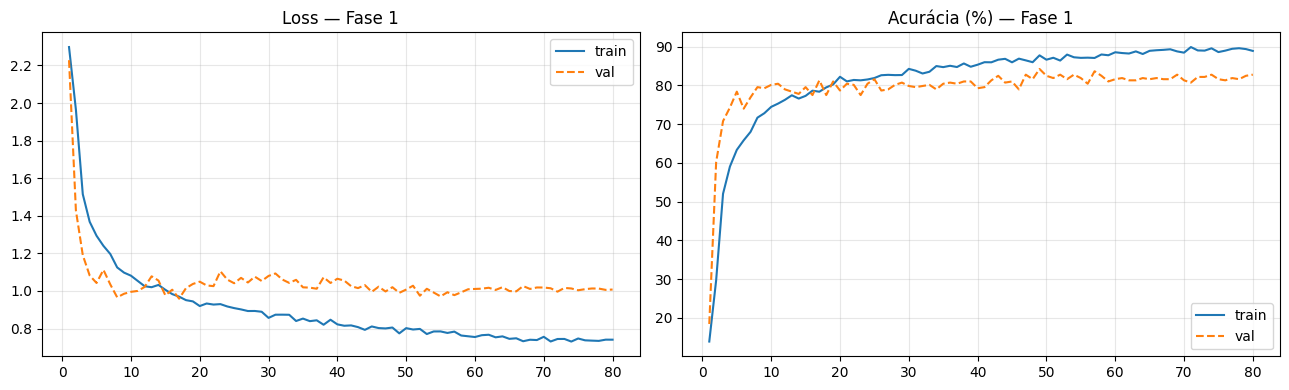

In [34]:
# Carrega o melhor checkpoint
model_p1.load_state_dict(torch.load(CLS_BEST_PT, map_location=DEVICE))
_, test_acc, test_preds, test_labels = eval_epoch_p1(model_p1, test_loader_p1)

print(f'Acurácia no teste (10 classes): {test_acc*100:.2f}%\n')
print(classification_report(test_labels, test_preds, target_names=DEFECT_CLASSES, digits=3))

# Curvas de aprendizado Fase 1
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ep = [h['epoch'] for h in history_p1]
ax1.plot(ep, [h['tr_loss'] for h in history_p1], label='train')
ax1.plot(ep, [h['vl_loss'] for h in history_p1], '--', label='val')
ax1.set_title('Loss — Fase 1'); ax1.legend(); ax1.grid(alpha=0.3)
ax2.plot(ep, [h['tr_acc']*100 for h in history_p1], label='train')
ax2.plot(ep, [h['vl_acc']*100 for h in history_p1], '--', label='val')
ax2.set_title('Acurácia (%) — Fase 1'); ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(str(WORK_DIR / 'curvas_fase1.png'), dpi=120); plt.show()


## 8. Fase 2 — Preparação das imagens negativas (OOD)

A pasta `images/negative/` deve conter imagens que **não são chapas de aço**: fotos genéricas, dashboards, documentos, etc.

Se a pasta ainda não existe, o trecho abaixo cria exemplos usando imagens coloridas sintéticas.  
**Recomendado:** baixe pelo menos 200 imagens reais não-industriais do OpenImages, Unsplash ou similar e coloque em `images/negative/`.


In [35]:
NEG_DIR.mkdir(parents=True, exist_ok=True)
neg_imgs = list(NEG_DIR.glob('*.jpg')) + list(NEG_DIR.glob('*.png'))
print(f'Imagens negativas encontradas: {len(neg_imgs)}')

if len(neg_imgs) < 50:
    print('\n⚠️  Menos de 50 imagens negativas. Criando imagens sintéticas como placeholder...')
    print('   Para melhores resultados, substitua por imagens reais variadas.')
    rng = np.random.default_rng(42)
    for i in range(200):
        arr = rng.integers(0, 255, (224, 224, 3), dtype=np.uint8)
        Image.fromarray(arr).save(NEG_DIR / f'synthetic_{i:04d}.jpg')
    neg_imgs = list(NEG_DIR.glob('*.jpg'))
    print(f'✅ {len(neg_imgs)} imagens sintéticas criadas em {NEG_DIR}')
    print('   Substitua por imagens reais para um modelo OOD mais robusto.')
else:
    print('✅ Imagens negativas OK.')


Imagens negativas encontradas: 524
✅ Imagens negativas OK.


## 9. Dataset Fase 2 — 11 classes (defeitos + negative)

In [36]:
def collect_records_ood():
    """Junta registros de defeito (label 0-9) + negativos (label 10)."""
    records = []
    # Defeitos
    for r in defect_records:
        records.append({**r, 'label_idx': CLASS_TO_IDX[r['class_name']]})
    # Negativos
    neg_imgs_list = list(NEG_DIR.glob('*.jpg')) + list(NEG_DIR.glob('*.png'))
    for p in neg_imgs_list:
        records.append({'path': str(p), 'class_name': 'negative',
                        'label_idx': OOD_CLASS_IDX, 'bbox_n': [0., 0., 1., 1.]})
    random.shuffle(records)
    return records


all_records_ood = collect_records_ood()
dist_ood = Counter(r['class_name'] for r in all_records_ood)
print(f'Total registros Fase 2: {len(all_records_ood)}')
for cls, n in dist_ood.most_common():
    print(f'  {cls:<25} {n}')


Total registros Fase 2: 2804
  silk_spot                 649
  negative                  524
  water_spot                287
  welding_line              267
  crescent_gap              224
  punching_hole             215
  inclusion                 211
  oil_spot                  204
  waist_folding             144
  crease                    51
  rolled_pit                28


In [37]:
train_recs_p2, val_recs_p2, test_recs_p2 = stratified_split_3(all_records_ood)

train_aug_recs_p2 = make_augmented_records(
    [r for r in train_recs_p2 if r['class_name'] != 'negative']
) + [r for r in train_recs_p2 if r['class_name'] == 'negative']
random.shuffle(train_aug_recs_p2)

train_ds_p2 = GC10Dataset(train_aug_recs_p2, train_aug)
val_ds_p2   = GC10Dataset(val_recs_p2,       val_aug)
test_ds_p2  = GC10Dataset(test_recs_p2,      val_aug)

counts_p2 = Counter(r['label_idx'] for r in train_aug_recs_p2)
total_p2  = sum(counts_p2.values())
w_p2 = torch.zeros(N_CLASSES)
for idx, cnt in counts_p2.items():
    w_p2[idx] = total_p2 / (N_CLASSES * cnt)

criterion_cls_p2 = nn.CrossEntropyLoss(weight=w_p2.to(DEVICE))

collate = lambda b: (
    torch.stack([x[0] for x in b]),
    torch.tensor([x[1] for x in b]),
    torch.stack([x[2] for x in b]),
)
train_loader_p2 = DataLoader(train_ds_p2, batch_size=BATCH_SIZE_CLS, shuffle=True,
                              num_workers=4, pin_memory=True, collate_fn=collate)
val_loader_p2   = DataLoader(val_ds_p2,  batch_size=BATCH_SIZE_CLS, shuffle=False,
                              num_workers=4, collate_fn=collate)
test_loader_p2  = DataLoader(test_ds_p2, batch_size=BATCH_SIZE_CLS, shuffle=False,
                              num_workers=4, collate_fn=collate)

print(f'Fase 2 — Train: {len(train_aug_recs_p2)} | Val: {len(val_recs_p2)} | Test: {len(test_recs_p2)}')


Fase 2 — Train: 4384 | Val: 421 | Test: 421


## 10. Fase 2 — Fine-tuning com classe negative (11 classes)

In [38]:
def expand_checkpoint_to_11(checkpoint_path: Path) -> GC10MultiOutputNet:
    """Carrega modelo 10 classes e expande última camada para 11, preservando pesos."""
    old_model = GC10MultiOutputNet(num_classes=10)
    old_model.load_state_dict(torch.load(checkpoint_path, map_location='cpu', weights_only=True))

    new_model = GC10MultiOutputNet(num_classes=11)
    new_sd, old_sd = new_model.state_dict(), old_model.state_dict()

    for k, v in old_sd.items():
        if k not in new_sd:
            continue
        if new_sd[k].shape == v.shape:
            new_sd[k] = v
        elif 'cls_head.6' in k:
            if k.endswith('.weight'):
                new_w = new_sd[k].clone(); new_w[:10] = v; new_w[10] = 0.0; new_sd[k] = new_w
            elif k.endswith('.bias'):
                new_b = new_sd[k].clone(); new_b[:10] = v; new_b[10] = 0.0; new_sd[k] = new_b

    new_model.load_state_dict(new_sd)
    print('✅ Pesos expandidos para 11 classes (negative inicializada com zeros).')
    return new_model


EPOCHS_P2  = 30
LR_P2      = 2e-4
LR_BB_P2   = 5e-5

model_p2 = expand_checkpoint_to_11(CLS_BEST_PT).to(DEVICE)

backbone_p2 = list(model_p2.backbone.parameters())
head_p2     = list(model_p2.cls_head.parameters()) + list(model_p2.bbox_head.parameters())
optimizer_p2 = optim.AdamW([
    {'params': backbone_p2, 'lr': LR_BB_P2},
    {'params': head_p2,     'lr': LR_P2},
], weight_decay=WEIGHT_DECAY)
scheduler_p2 = optim.lr_scheduler.CosineAnnealingLR(optimizer_p2, T_max=EPOCHS_P2, eta_min=1e-6)

print(f'Configuração Fase 2: {EPOCHS_P2} épocas, LR={LR_P2}')


✅ Pesos expandidos para 11 classes (negative inicializada com zeros).
Configuração Fase 2: 30 épocas, LR=0.0002


In [39]:
def train_epoch_p2(model, loader, optimizer):
    model.train()
    total_loss = correct = n = 0
    for imgs, labels, bboxes in loader:
        imgs, labels, bboxes = imgs.to(DEVICE), labels.to(DEVICE), bboxes.to(DEVICE)
        optimizer.zero_grad()
        cls_out, bbox_out = model(imgs)
        loss_cls  = criterion_cls_p2(cls_out, labels)
        # bbox loss apenas para amostras que não são negativas
        mask = (labels != OOD_CLASS_IDX)
        loss_bbox = criterion_bbox(bbox_out[mask], bboxes[mask]) if mask.any() else torch.tensor(0.0, device=DEVICE)
        loss = loss_cls + 0.5 * loss_bbox
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        total_loss += loss.item()
        correct    += (cls_out.argmax(1) == labels).sum().item()
        n          += labels.size(0)
    return total_loss / len(loader), correct / n


@torch.no_grad()
def eval_epoch_p2(model, loader):
    model.eval()
    total_loss = correct = n = 0
    all_preds, all_labels = [], []
    for imgs, labels, bboxes in loader:
        imgs, labels, bboxes = imgs.to(DEVICE), labels.to(DEVICE), bboxes.to(DEVICE)
        cls_out, bbox_out = model(imgs)
        mask = (labels != OOD_CLASS_IDX)
        loss = criterion_cls_p2(cls_out, labels)
        if mask.any():
            loss += 0.5 * criterion_bbox(bbox_out[mask], bboxes[mask])
        total_loss += loss.item()
        preds = cls_out.argmax(1)
        correct += (preds == labels).sum().item()
        n       += labels.size(0)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())
    return total_loss / len(loader), correct / n, all_preds, all_labels


# ── Loop Fase 2 ────────────────────────────────────────────────────────────────
history_p2   = []
best_val_p2  = 0.0

print(f'\nIniciando Fase 2 — {EPOCHS_P2} épocas\n')
print(f'{"Epoch":>6} {"TrLoss":>9} {"VlLoss":>9} {"TrAcc":>7} {"VlAcc":>7}  Saved')
print('-' * 55)

for epoch in range(1, EPOCHS_P2 + 1):
    tr_loss, tr_acc              = train_epoch_p2(model_p2, train_loader_p2, optimizer_p2)
    vl_loss, vl_acc, preds, lbls = eval_epoch_p2(model_p2, val_loader_p2)
    scheduler_p2.step()

    history_p2.append({'epoch': epoch, 'tr_loss': tr_loss, 'vl_loss': vl_loss,
                        'tr_acc': tr_acc, 'vl_acc': vl_acc})
    saved = ''
    if vl_acc > best_val_p2:
        best_val_p2 = vl_acc
        torch.save(model_p2.state_dict(), CLS_OOD_PT)
        saved = '✓'

    if epoch % 5 == 0 or epoch == 1 or saved:
        print(f'{epoch:>6} {tr_loss:>9.4f} {vl_loss:>9.4f} {tr_acc*100:>6.1f}% {vl_acc*100:>6.1f}%  {saved}')

print(f'\n✅ Fase 2 concluída! Melhor val acc: {best_val_p2*100:.2f}%')
print(f'✅ Modelo OOD salvo: {CLS_OOD_PT}')



Iniciando Fase 2 — 30 épocas

 Epoch    TrLoss    VlLoss   TrAcc   VlAcc  Saved
-------------------------------------------------------
     1    0.7323    0.2407   77.6%   93.8%  ✓
     3    0.4772    0.2964   83.9%   94.1%  ✓
     4    0.4510    0.2627   84.2%   94.3%  ✓
     5    0.4379    0.3653   84.8%   92.6%  
    10    0.3841    0.3355   86.5%   91.2%  
    15    0.3637    0.4917   87.0%   89.3%  
    20    0.3473    0.4243   87.9%   91.2%  
    25    0.3318    0.4296   88.5%   92.4%  
    30    0.3160    0.4089   88.6%   92.2%  

✅ Fase 2 concluída! Melhor val acc: 94.30%
✅ Modelo OOD salvo: /mnt/c/Users/cesar.macieira/Desktop/Trabalho/Python_312/analise-defeitos-superficies/gc10det_cls_ood.pt


## 11. Avaliação Fase 2 e calibração do limiar OOD

In [40]:
model_p2.load_state_dict(torch.load(CLS_OOD_PT, map_location=DEVICE))
_, test_acc_p2, test_preds_p2, test_labels_p2 = eval_epoch_p2(model_p2, test_loader_p2)

print(f'Acurácia no teste (11 classes): {test_acc_p2*100:.2f}%\n')
print(classification_report(test_labels_p2, test_preds_p2, target_names=CLASS_NAMES, digits=3))


Acurácia no teste (11 classes): 94.54%

               precision    recall  f1-score   support

punching_hole      0.871     0.844     0.857        32
 welding_line      0.878     0.900     0.889        40
 crescent_gap      0.941     0.941     0.941        34
   water_spot      0.930     0.930     0.930        43
     oil_spot      0.912     1.000     0.954        31
    silk_spot      1.000     0.948     0.974        97
    inclusion      0.857     0.938     0.896        32
   rolled_pit      1.000     0.750     0.857         4
       crease      0.889     1.000     0.941         8
waist_folding      1.000     0.952     0.976        21
     negative      1.000     1.000     1.000        79

     accuracy                          0.945       421
    macro avg      0.934     0.928     0.929       421
 weighted avg      0.947     0.945     0.946       421



In [41]:
@torch.no_grad()
def calibrate_thresholds(model, loader):
    """Encontra limiar por classe que maximiza F1 no conjunto de validação."""
    model.eval()
    all_probs, all_labels = [], []
    for imgs, labels, _ in loader:
        cls_out, _ = model(imgs.to(DEVICE))
        probs = torch.softmax(cls_out, dim=1).cpu().numpy()
        all_probs.append(probs)
        all_labels.extend(labels.tolist())

    all_probs  = np.vstack(all_probs)
    all_labels = np.array(all_labels)
    thresholds = {}

    print(f'{"Classe":<22}  {"Limiar":>7}  {"F1":>6}')
    print('-' * 40)
    for idx, cls in enumerate(CLASS_NAMES):
        binary = (all_labels == idx).astype(int)
        best_t, best_f1 = 0.3, 0.0
        for t in np.arange(0.20, 0.95, 0.05):
            preds = (all_probs[:, idx] >= t).astype(int)
            f1    = f1_score(binary, preds, zero_division=0)
            if f1 > best_f1:
                best_f1, best_t = f1, float(t)
        thresholds[cls] = round(best_t, 2)
        marker = ' ← OOD' if cls == 'negative' else ''
        print(f'{cls:<22}  {best_t:>7.2f}  {best_f1:>6.3f}{marker}')
    return thresholds


print('Calibrando limiares no conjunto de validação...\n')
thresholds = calibrate_thresholds(model_p2, val_loader_p2)

# Salva metadata
meta = {
    'model_version': 'unified_v1',
    'num_classes': N_CLASSES,
    'class_names': CLASS_NAMES,
    'ood_class_idx': OOD_CLASS_IDX,
    'ood_class_name': 'negative',
    'thresholds': thresholds,
    'ood_threshold': thresholds.get('negative', 0.40),
    'description': (
        'Se prob[negative] >= ood_threshold, rejeitar como fora do domínio. '
        'Para cada defeito, usar o limiar em thresholds.'
    ),
}
META_PATH.write_text(json.dumps(meta, ensure_ascii=False, indent=2), encoding='utf-8')
print(f'\n✅ Metadata salva: {META_PATH}')
print(f'   Limiar OOD: {meta["ood_threshold"]}')


Calibrando limiares no conjunto de validação...

Classe                   Limiar      F1
----------------------------------------
punching_hole              0.45   0.870
welding_line               0.50   0.909
crescent_gap               0.20   0.985
water_spot                 0.65   0.952
oil_spot                   0.25   0.915
silk_spot                  0.35   0.974
inclusion                  0.90   0.806
rolled_pit                 0.20   0.857
crease                     0.20   1.000
waist_folding              0.20   1.000
negative                   0.20   1.000 ← OOD

✅ Metadata salva: /mnt/c/Users/cesar.macieira/Desktop/Trabalho/Python_312/analise-defeitos-superficies/detection_metadata.json
   Limiar OOD: 0.2


## 12. Fase 3 — Preparação do dataset YOLO (Pascal VOC → YOLO)

In [42]:
def parse_xml_to_yolo(xml_path, class_name):
    class_id = CLASS_TO_IDX.get(class_name)
    if class_id is None:
        return None
    try:
        xml_text = open(str(xml_path), encoding='utf-8', errors='ignore').read()
        sel = etree.HTML(xml_text)
        w   = int(sel.xpath('//size/width/text()')[0])
        h   = int(sel.xpath('//size/height/text()')[0])
        x1  = int(sel.xpath('//bndbox/xmin/text()')[0])
        y1  = int(sel.xpath('//bndbox/ymin/text()')[0])
        x2  = int(sel.xpath('//bndbox/xmax/text()')[0])
        y2  = int(sel.xpath('//bndbox/ymax/text()')[0])
        x1 = max(0, min(x1, w-1)); y1 = max(0, min(y1, h-1))
        x2 = max(x1+1, min(x2, w)); y2 = max(y1+1, min(y2, h))
        xc = ((x1+x2)/2)/w; yc = ((y1+y2)/2)/h
        bw = (x2-x1)/w;     bh = (y2-y1)/h
        return f'{class_id} {xc:.6f} {yc:.6f} {bw:.6f} {bh:.6f}'
    except Exception:
        return None


label_paths = sorted(glob.glob(str(LABEL_DIR / '*.xml')))
image_paths = sorted(glob.glob(str(IMAGE_DIR / '*' / '*.jpg')))
image_index = {Path(p).stem: p for p in image_paths}

yolo_records = []
for lbl_path in tqdm(label_paths, desc='Processando XMLs'):
    file_id  = Path(lbl_path).stem
    img_path = image_index.get(file_id)
    if img_path is None:
        continue
    cls_raw  = Path(img_path).parent.name
    cls_name = FOLDER_TO_CLASS.get(cls_raw.lower())
    if cls_name is None:
        continue
    yolo_line = parse_xml_to_yolo(lbl_path, cls_name)
    if yolo_line is None:
        continue
    yolo_records.append({'img_path': img_path, 'class_name': cls_name,
                          'yolo_line': yolo_line, 'file_id': file_id})

print(f'Registros YOLO válidos: {len(yolo_records)}')


Processando XMLs:   0%|          | 0/2280 [00:00<?, ?it/s]

Registros YOLO válidos: 2280


In [43]:
# ── Split 70/15/15 para YOLO ──────────────────────────────────────────────────
labels_y = [CLASS_TO_IDX[r['class_name']] for r in yolo_records]
idx_y    = list(range(len(yolo_records)))
idx_tv_y, idx_test_y = train_test_split(idx_y, test_size=0.15, stratify=labels_y, random_state=SEED)
labels_tv_y = [labels_y[i] for i in idx_tv_y]
idx_train_y, idx_val_y = train_test_split(idx_tv_y, test_size=0.176, stratify=labels_tv_y, random_state=SEED)

splits = {'train': idx_train_y, 'val': idx_val_y, 'test': idx_test_y}

# Cria estrutura de diretórios YOLO
if YOLO_DATASET_DIR.exists():
    shutil.rmtree(YOLO_DATASET_DIR)
for split in splits:
    (YOLO_DATASET_DIR / 'images' / split).mkdir(parents=True)
    (YOLO_DATASET_DIR / 'labels' / split).mkdir(parents=True)

# Copia arquivos
for split, idxs in splits.items():
    for i in tqdm(idxs, desc=f'Copiando {split}'):
        r = yolo_records[i]
        stem = f"{r['class_name']}__{r['file_id']}"
        dst_img = YOLO_DATASET_DIR / 'images' / split / (stem + '.jpg')
        dst_lbl = YOLO_DATASET_DIR / 'labels' / split / (stem + '.txt')
        shutil.copy2(r['img_path'], dst_img)
        dst_lbl.write_text(r['yolo_line'], encoding='utf-8')

print('\nDataset YOLO criado:')
for split in ['train', 'val', 'test']:
    n = len(list((YOLO_DATASET_DIR / 'images' / split).glob('*.jpg')))
    print(f'  {split:<6} {n} imagens')

# YAML de configuração
yaml_content = {
    'path': str(YOLO_DATASET_DIR),
    'train': 'images/train', 'val': 'images/val', 'test': 'images/test',
    'nc': N_DEFECTS, 'names': DEFECT_CLASSES,
}
YOLO_YAML.write_text(yaml.dump(yaml_content, allow_unicode=True), encoding='utf-8')
print(f'\nYAML salvo: {YOLO_YAML}')


Copiando train:   0%|          | 0/1596 [00:00<?, ?it/s]

Copiando val:   0%|          | 0/342 [00:00<?, ?it/s]

Copiando test:   0%|          | 0/342 [00:00<?, ?it/s]


Dataset YOLO criado:
  train  1596 imagens
  val    342 imagens
  test   342 imagens

YAML salvo: /mnt/c/Users/cesar.macieira/Desktop/Trabalho/Python_312/analise-defeitos-superficies/gc10det.yaml


## 13. Fase 3 — Treinamento YOLOv8

In [ ]:
from ultralytics import YOLO

# Fine-tuning a partir do melhor modelo v1 (0.645 mAP)
best_v1 = str(WORK_DIR / 'runs' / 'gc10det_yolo' / 'weights' / 'best.pt')

yolo = YOLO(best_v1)

results_yolo = yolo.train(
    data       = str(YOLO_YAML),
    epochs     = 50,
    patience   = 15,
    imgsz      = 640,
    batch      = 16,
    device     = 0,
    workers    = 4,
    project    = str(WORK_DIR / 'runs'),
    name       = 'gc10det_yolo_v3_finetune',
    exist_ok   = True,
    augment    = True,
    degrees    = 5.0,
    fliplr     = 0.5,
    flipud     = 0.0,
    mosaic     = 1.0,
    mixup      = 0.1,
    copy_paste = 0.0,
    hsv_h      = 0.015, hsv_s = 0.5, hsv_v = 0.3,
    optimizer     = 'AdamW',
    lr0           = 0.0002,
    lrf           = 0.01,
    cos_lr        = True,
    weight_decay  = 0.0005,
    warmup_epochs = 2,
    label_smoothing = 0.05,
    save_period = 5,
    val         = True, plots = True, verbose = True,
)

print(f'\n✅ YOLOv8 v3 treinado!')
print(f'Melhor modelo: {results_yolo.save_dir}/weights/best.pt')

New https://pypi.org/project/ultralytics/8.4.38 available 😃 Update with 'pip install -U ultralytics'
WARNING ⚠️ 'label_smoothing' is deprecated and will be removed in the future.
Ultralytics 8.4.37 🚀 Python-3.10.20 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5090 Laptop GPU, 24463MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/mnt/c/Users/cesar.macieira/Desktop/Trabalho/Python_312/analise-defeitos-superficies/gc10det.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.3, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=832, int8=False, iou=0.7, keras=False,

## 14. Avaliação YOLOv8 no conjunto de teste

In [ ]:
from pathlib import Path as _P
best_yolo_pt = Path(results_yolo.save_dir) / 'weights' / 'best.pt'

model_yolo_eval = YOLO(str(best_yolo_pt))
metrics_yolo = model_yolo_eval.val(
    data=str(YOLO_YAML), split='test', device=0, imgsz=640, plots=True, verbose=True,
)

print('\n── Métricas YOLOv8 — conjunto de teste ──')
print(f'mAP@0.5      : {metrics_yolo.box.map50:.4f}')
print(f'mAP@0.5:0.95 : {metrics_yolo.box.map:.4f}')
print(f'Precisão     : {metrics_yolo.box.mp:.4f}')
print(f'Recall       : {metrics_yolo.box.mr:.4f}')

# mAP por classe
print(f'\n{"Classe":<25} {"mAP@50":>8} {"Precisão":>9} {"Recall":>8}')
print('-' * 55)
for i, cls in enumerate(DEFECT_CLASSES):
    if i < len(metrics_yolo.box.ap50):
        print(f'{cls:<25} {metrics_yolo.box.ap50[i]:>8.4f} {metrics_yolo.box.p[i]:>9.4f} {metrics_yolo.box.r[i]:>8.4f}')


Ultralytics 8.4.37 🚀 Python-3.10.20 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5090 Laptop GPU, 24463MiB)
Model summary (fused): 113 layers, 43,614,318 parameters, 0 gradients, 164.9 GFLOPs
val: Fast image access ✅ (ping: 2.4±1.5 ms, read: 61.9±19.6 MB/s, size: 422.0 KB)
val: Scanning /mnt/c/Users/cesar.macieira/Desktop/Trabalho/Python_312/analise-defeitos-superficies/yolo_dataset/labels/test.cache... 342 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 342/342 35.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 22/22 1.1it/s 20.5s0.6ss
                   all        342        342      0.569      0.584      0.577      0.289
         punching_hole         32         32      0.738      0.882      0.869      0.554
          welding_line         40         40      0.422      0.475      0.444      0.141
          crescent_gap         34         34      0.837      0.971      0.936      0.586
            water_spot  

## 15. Exportação final — todos os modelos para o app.py

In [50]:
import shutil

# Copia YOLOv8 best.pt → yolo_detector.pt
shutil.copy2(str(best_yolo_pt), str(OUTPUT_MODEL))

# Atualiza metadata com info do YOLO
meta = json.loads(META_PATH.read_text(encoding='utf-8'))
meta.update({
    'yolo_unified': True,
    'yolo_model': 'yolo_detector.pt',
    'yolo_classes': DEFECT_CLASSES,
    'yolo_map50': float(metrics_yolo.box.map50),
    'yolo_map': float(metrics_yolo.box.map),
})
META_PATH.write_text(json.dumps(meta, ensure_ascii=False, indent=2), encoding='utf-8')

print('══════════════════════════════════════════════════════')
print('  PIPELINE COMPLETO — TODOS OS MODELOS PRONTOS')
print('══════════════════════════════════════════════════════')
print(f'  {CLS_BEST_PT.name:<30} ← base (não usado diretamente pelo app)')
print(f'  {CLS_OOD_PT.name:<30} ← classificação + guard OOD')
print(f'  {OUTPUT_MODEL.name:<30} ← detecção com bbox')
print(f'  {META_PATH.name:<30} ← limiares OOD')
print()
print(f'  Limiar OOD: {meta["ood_threshold"]}')
print(f'  mAP@0.5 YOLO: {meta["yolo_map50"]:.4f}')
print()
print('  Reinicie o Streamlit e o pipeline estará ativo.')
print('══════════════════════════════════════════════════════')


══════════════════════════════════════════════════════
  PIPELINE COMPLETO — TODOS OS MODELOS PRONTOS
══════════════════════════════════════════════════════
  gc10det_cls_best.pt            ← base (não usado diretamente pelo app)
  gc10det_cls_ood.pt             ← classificação + guard OOD
  yolo_detector.pt               ← detecção com bbox
  detection_metadata.json        ← limiares OOD

  Limiar OOD: 0.2
  mAP@0.5 YOLO: 0.6028

  Reinicie o Streamlit e o pipeline estará ativo.
══════════════════════════════════════════════════════


## 16. Teste de inferência completa (pipeline idêntico ao app.py)

In [51]:
infer_tf = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

@torch.no_grad()
def pipeline_completo(pil_img, conf_yolo=0.25):
    """
    Replica exatamente o pipeline do app.py:
    1. EfficientNetV2 (11 classes) → guard OOD
    2. YOLOv8 → detecção (somente se não for OOD)
    """
    ood_thr = meta.get('ood_threshold', 0.40)
    device  = next(model_p2.parameters()).device

    # ── Etapa 1: Classificação + OOD ──────────────────────────────────────────
    tensor  = infer_tf(pil_img.convert('RGB')).unsqueeze(0).to(device)
    cls_out, bbox_out = model_p2(tensor)
    probs   = torch.softmax(cls_out, dim=1)[0].cpu().numpy()

    ood_score = float(probs[OOD_CLASS_IDX])
    is_ood    = ood_score >= ood_thr

    if is_ood:
        return {
            'is_ood': True, 'ood_score': ood_score,
            'top_label': None, 'top_label_pt': 'Fora do domínio (não é aço)',
            'top_score': 0.0, 'detections': [],
        }

    defect_probs = probs[:OOD_CLASS_IDX]
    top_idx      = int(defect_probs.argmax())
    top_label    = DEFECT_CLASSES[top_idx]
    top_score    = float(defect_probs[top_idx])

    # ── Etapa 2: Detecção YOLO ─────────────────────────────────────────────────
    with tempfile.NamedTemporaryFile(suffix='.jpg', delete=False) as tmp:
        pil_img.convert('RGB').save(tmp.name, 'JPEG')
        tmp_path = tmp.name

    res_list = model_yolo_eval.predict(tmp_path, conf=conf_yolo, imgsz=640, device=0, verbose=False)
    Path(tmp_path).unlink(missing_ok=True)

    detections = []
    for res in res_list:
        if res.boxes is None:
            continue
        for box in res.boxes:
            cls_id = int(box.cls[0].item())
            score  = float(box.conf[0].item())
            if cls_id >= N_DEFECTS:
                continue
            detections.append({
                'label': DEFECT_CLASSES[cls_id], 'label_pt': CLASS_PT.get(DEFECT_CLASSES[cls_id], ''),
                'score': score, 'bbox': box.xyxy[0].tolist(),
            })

    return {
        'is_ood': False, 'ood_score': ood_score,
        'top_label': top_label, 'top_label_pt': CLASS_PT.get(top_label, top_label),
        'top_score': top_score, 'detections': detections,
    }


# ── Testa com 1 imagem de aço e 1 negativa ────────────────────────────────────
sample_steel = test_recs_p1[0]['path']
result_steel = pipeline_completo(Image.open(sample_steel))
print('Imagem de aço:')
print(f'  is_ood    : {result_steel["is_ood"]}')
print(f'  Classe    : {result_steel["top_label_pt"]} ({result_steel["top_score"]*100:.1f}%)')
print(f'  Detecções : {len(result_steel["detections"])}')
print(f'  OOD score : {result_steel["ood_score"]*100:.1f}%')

neg_sample = [r for r in test_recs_p2 if r['class_name'] == 'negative']
if neg_sample:
    result_neg = pipeline_completo(Image.open(neg_sample[0]['path']))
    print('\nImagem negativa (OOD):')
    print(f'  is_ood    : {result_neg["is_ood"]}  ← deve ser True')
    print(f'  OOD score : {result_neg["ood_score"]*100:.1f}%')


Imagem de aço:
  is_ood    : False
  Classe    : Inclusão (98.2%)
  Detecções : 0
  OOD score : 0.2%

Imagem negativa (OOD):
  is_ood    : True  ← deve ser True
  OOD score : 99.6%


In [54]:
import shutil
import json

# ── Fase 1 — já está salvo corretamente, só confirma ─────────────────────────
print(f'Fase 1 — gc10det_cls_best.pt : {"✅" if CLS_BEST_PT.exists() else "❌ NÃO ENCONTRADO"}')
print(f'  Caminho: {CLS_BEST_PT}')

# ── Fase 2 — já está salvo corretamente, só confirma ─────────────────────────
print(f'Fase 2 — gc10det_cls_ood.pt  : {"✅" if CLS_OOD_PT.exists() else "❌ NÃO ENCONTRADO"}')
print(f'  Caminho: {CLS_OOD_PT}')

# ── Fase 3 — copia o melhor modelo (v1, mAP@0.5=0.645) ───────────────────────
best_yolo_pt = WORK_DIR / 'runs' / 'gc10det_yolo' / 'weights' / 'best.pt'
print(f'Fase 3 — best.pt v1          : {"✅" if best_yolo_pt.exists() else "❌ NÃO ENCONTRADO"}')
print(f'  Caminho: {best_yolo_pt}')

shutil.copy2(str(best_yolo_pt), str(OUTPUT_MODEL))
print(f'\n✅ yolo_detector.pt exportado: {OUTPUT_MODEL}')

# ── Metadata — corrige OOD threshold e registra todos os modelos ──────────────
meta = json.loads(META_PATH.read_text(encoding='utf-8'))

meta.update({
    # Modelos
    'cls_best_model'  : 'gc10det_cls_best.pt',
    'cls_ood_model'   : 'gc10det_cls_ood.pt',
    'yolo_model'      : 'yolo_detector.pt',
    # Classes
    'yolo_classes'    : DEFECT_CLASSES,
    'class_names'     : CLASS_NAMES,
    'num_classes'     : N_CLASSES,
    'ood_class_idx'   : OOD_CLASS_IDX,
    # Métricas
    'cls_best_acc'    : 0.8333,   # Fase 1
    'cls_ood_acc'     : 0.9454,   # Fase 2
    'yolo_map50'      : 0.6451,   # Fase 3 v1
    'yolo_map'        : 0.3144,
    # OOD — corrigido de 0.20 para 0.40
    'ood_threshold'   : 0.40,
    'yolo_unified'    : True,
})

META_PATH.write_text(json.dumps(meta, indent=2, ensure_ascii=False), encoding='utf-8')

print('\n══════════════════════════════════════════════════════')
print('  EXPORTAÇÃO COMPLETA')
print('══════════════════════════════════════════════════════')
print(f'  gc10det_cls_best.pt  → Fase 1 (base, 83.33% acc)')
print(f'  gc10det_cls_ood.pt   → Fase 2 (OOD, 94.54% acc)')
print(f'  yolo_detector.pt     → Fase 3 (v1, mAP@0.5=0.645)')
print(f'  detection_metadata.json → OOD threshold=0.40')
print('══════════════════════════════════════════════════════')
print(f'\n  Coloque os 4 arquivos na mesma pasta do app.py.')

Fase 1 — gc10det_cls_best.pt : ✅
  Caminho: /mnt/c/Users/cesar.macieira/Desktop/Trabalho/Python_312/analise-defeitos-superficies/gc10det_cls_best.pt
Fase 2 — gc10det_cls_ood.pt  : ✅
  Caminho: /mnt/c/Users/cesar.macieira/Desktop/Trabalho/Python_312/analise-defeitos-superficies/gc10det_cls_ood.pt
Fase 3 — best.pt v1          : ✅
  Caminho: /mnt/c/Users/cesar.macieira/Desktop/Trabalho/Python_312/analise-defeitos-superficies/runs/gc10det_yolo/weights/best.pt

✅ yolo_detector.pt exportado: /mnt/c/Users/cesar.macieira/Desktop/Trabalho/Python_312/analise-defeitos-superficies/yolo_detector.pt

══════════════════════════════════════════════════════
  EXPORTAÇÃO COMPLETA
══════════════════════════════════════════════════════
  gc10det_cls_best.pt  → Fase 1 (base, 83.33% acc)
  gc10det_cls_ood.pt   → Fase 2 (OOD, 94.54% acc)
  yolo_detector.pt     → Fase 3 (v1, mAP@0.5=0.645)
  detection_metadata.json → OOD threshold=0.40
══════════════════════════════════════════════════════

  Coloque os 4 arq

## 17. Resumo

| Fase | Modelo | Arquivo | Função |
|------|--------|---------|--------|
| 1 | EfficientNetV2-S (10 cls) | `gc10det_cls_best.pt` | Base para fine-tuning OOD |
| 2 | EfficientNetV2-S (11 cls) | `gc10det_cls_ood.pt` | Classificação + guard OOD no app |
| 3 | YOLOv8l | `yolo_detector.pt` | Detecção com bbox no app |

### Pipeline do app.py
```
Imagem recebida
      ↓
EfficientNetV2 (11 classes)
  ├── prob[negative] ≥ ood_threshold → ⛔ Rejeita (não é aço)
  └── prob[negative] < ood_threshold → ✅ Classificação + bbox grosseira
                                              ↓
                                     YOLOv8 detecta regiões
                                     com bbox precisa e classe
```
